# 🤖 SciFi Forge — V2 QLoRA Fine-Tuning

**Fine-tuning Qwen2.5-1.5B-Instruct on the SciFi corpus using 4-bit QLoRA.**

This notebook orchestrates V2 by calling the production `.py` modules.

| File | Responsibility |
|---|---|
| `data/prepare_dataset.py` | Chunk corpus → 50k instruction-format JSONL |
| `data/verify_dataset.py` | Sanity-check dataset before training |
| `v2_finetuned/model_config.py` | All hyperparameters and paths |
| `v2_finetuned/finetune.py` | QLoRA training → `v2_finetuned/adapters/` |
| `v2_finetuned/generate.py` | Inference with trained adapters |
| `v2_finetuned/evaluate.py` | BLEU-2/4, perplexity, speed → `eval_results_v2.json` |

**VRAM budget:** ~5.5GB peak — safe on 8GB GPU.

## 0. Setup

In [1]:
import os, sys, site, ctypes
from pathlib import Path

# ── Pre-load libnvJitLink.so.13 before bitsandbytes is imported ───────────
# Setting LD_LIBRARY_PATH after Python starts doesn't affect ctypes.CDLL
# resolution, but explicitly loading the .so puts it in the process cache
# so any subsequent dlopen("libnvJitLink.so.13") finds it immediately.
for _sp in site.getsitepackages():
    _so = Path(_sp) / "nvidia/cu13/lib/libnvJitLink.so.13"
    if _so.exists():
        ctypes.CDLL(str(_so))
        print(f"Pre-loaded: {_so}")
        break

os.environ["TF_CPP_MIN_LOG_LEVEL"]      = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"]     = "0"
os.environ["TOKENIZERS_PARALLELISM"]    = "false"
os.environ["TRANSFORMERS_VERBOSITY"]    = "error"

ROOT = Path("../").resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "v2_finetuned"))
sys.path.insert(0, str(ROOT / "data"))

import torch
import gc

def clear_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

def vram_used():
    if not torch.cuda.is_available(): return "N/A"
    used  = torch.cuda.memory_allocated() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    return f"{used:.1f} / {total:.0f} GB"

print(f"Python : {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"VRAM   : {vram_used()}")

checks = [
    ROOT / "data/raw/internet_archive_scifi_v3.txt",
    ROOT / "v2_finetuned/model_config.py",
    ROOT / "v2_finetuned/finetune.py",
]
for p in checks:
    status = "✅" if p.exists() else "❌  MISSING"
    print(f"  {status}  {p.relative_to(ROOT)}")

Pre-loaded: /home/urmila/PycharmProjects/LanguageModel/.venv/lib/python3.12/site-packages/nvidia/cu13/lib/libnvJitLink.so.13
Python : 3.12.3
PyTorch: 2.10.0+cu130
CUDA   : True
GPU    : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM   : 0.0 / 8 GB
  ✅  data/raw/internet_archive_scifi_v3.txt
  ✅  v2_finetuned/model_config.py
  ✅  v2_finetuned/finetune.py


## 1. Prepare Dataset

Chunks the first 10M characters of the corpus into 50,000 instruction-format samples:  
`{"instruction": "Continue this science fiction story:", "input": "<passage>", "output": "<continuation>"}`

**Skip this section if `data/chunks/scifi_train.jsonl` already exists.**

In [2]:
TRAIN_JSONL = ROOT / "data/chunks/scifi_train.jsonl"
VAL_JSONL   = ROOT / "data/chunks/scifi_val.jsonl"

if TRAIN_JSONL.exists() and VAL_JSONL.exists():
    import json
    n_train = sum(1 for _ in open(TRAIN_JSONL))
    n_val   = sum(1 for _ in open(VAL_JSONL))
    print(f"Dataset already exists — skipping prep.")
    print(f"  Train: {n_train:,} samples  |  Val: {n_val:,} samples")
else:
    print("Dataset not found — running prepare_dataset.py ...")
    from data.prepare_dataset import run
    run(dry_run=False)   # change to dry_run=True for a 1000-sample smoke test

Dataset already exists — skipping prep.
  Train: 64 samples  |  Val: 3 samples


In [3]:
# ── Verify dataset quality before training ────────────────────────────────
from data.verify_dataset import verify
import random
random.seed(0)
passed = verify()
assert passed, "Dataset failed verification — fix errors above before training."


Checking train: /home/urmila/PycharmProjects/LanguageModel/data/chunks/scifi_train.jsonl
  Records loaded: 64
  Input  length — min:1743 p50:1792 p90:1825 max:1837 mean:1793.2
  Output length — min:402 p50:448 p90:448 max:448 mean:440.9

── Random Samples from train ──────────────────────────────

  [instruction] Continue this science fiction story:
  [input]  ..."g certain scientists to think along new lines. Klia had suggested a method for testing basic mental formative patterns in infancy; and now a western university's psychology department was setting up a"
  [output] 'research lab "for studying the basic affective reaction patterns of infants at birth". Klia, under another pen-name, had suggested an extension of relativistic mechanics to cover hypothetical N-dimens'...
  ────────────────────────────────────────────────────────────

  [instruction] Continue this science fiction story:
  [input]  ...'State.Working Hours. Occupation. Canadian residents send coupon to International 

In [4]:
# ── Preview a sample ──────────────────────────────────────────────────────
import json, random
samples = [json.loads(l) for l in open(TRAIN_JSONL)]
s = random.choice(samples)
print("INSTRUCTION:", s["instruction"])
print("\nINPUT (last 200 chars):")
print("...", s["input"][-200:])
print("\nOUTPUT (first 200 chars):")
print(s["output"][:200], "...")

INSTRUCTION: Continue this science fiction story:

INPUT (last 200 chars):
... dio -- TV Eng'r'ng Radio and TV Servicing Radio Operating Television -- Technician Air Brakes Car Inspector Diesel Locomotive Locomotive Engineer Section Foreman Combustion Engineering Diesel -- Elec.

OUTPUT (first 200 chars):
Diesel Eng's Electric Light and Power Stationary Fireman Stationary Steam Engineering Carding and Spinning Cotton, Rayon, Woolen Mfg. Finishing and Dyeing Loom Fixing Textile Designing Textile Eng'r'g ...


## 2. Fine-Tune — QLoRA

- Model: `Qwen/Qwen2.5-1.5B-Instruct` loaded in 4-bit (`nf4`, double quant, `bfloat16`)
- LoRA: `r=16`, `alpha=32`, targets `q_proj` + `v_proj`
- Optimiser: `paged_adamw_8bit`, `lr=2e-4`, `batch=1`, `grad_accum=8`
- Expected VRAM peak: ~5.5 GB
- Expected time: ~4–6 hours for 3 epochs on 8GB GPU

**To resume a crashed run:** change `resume=True` in the cell below.

In [5]:
# Check VRAM is clean before loading a large model
clear_gpu()
print(f"VRAM before load: {vram_used()}")

# Check adapters don't already exist (skip training if already done)
ADAPTER_DIR = ROOT / "v2_finetuned/adapters"
if (ADAPTER_DIR / "adapter_config.json").exists():
    print(f"\n⚠️  Adapters already exist at {ADAPTER_DIR}")
    print("   Delete them or set resume=True to retrain.")
else:
    print("No existing adapters found — ready to train.")

VRAM before load: 0.0 / 8 GB
No existing adapters found — ready to train.


In [6]:
# ── Run fine-tuning ───────────────────────────────────────────────────────
# This cell streams MLflow + HuggingFace Trainer logs live.
# Expected first loss: ~1.8-2.2  |  Final loss: ~1.0-1.3

from v2_finetuned.finetune import run_finetune

run_finetune(resume=False)   # change to resume=True to continue interrupted training

Loading tokeniser: Qwen/Qwen2.5-1.5B-Instruct


Loading model in 4-bit: Qwen/Qwen2.5-1.5B-Instruct
  VRAM before load: 0.00 GB


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

  VRAM after load:  1.17 GB
trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410
Loading datasets...
  Train: 64 samples | Val: 3 samples


Applying formatting function to train dataset:   0%|          | 0/64 [00:00<?, ? examples/s]

...

Applying formatting function to eval dataset:   0%|          | 0/3 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/3 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/3 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/3 [00:00<?, ? examples/s]


Starting training...
{'train_runtime': '48.74', 'train_samples_per_second': '3.94', 'train_steps_per_second': '0.492', 'train_loss': '4.528', 'entropy': '4.342', 'num_tokens': '8.984e+04', 'mean_token_accuracy': '0.2956', 'epoch': '3'}

Saving adapter weights → /home/urmila/PycharmProjects/LanguageModel/v2_finetuned/adapters
{'eval_loss': '4.099', 'eval_runtime': '0.2968', 'eval_samples_per_second': '10.11', 'eval_steps_per_second': '3.37', 'eval_entropy': '3.991', 'eval_num_tokens': '8.984e+04', 'eval_mean_token_accuracy': '0.3258', 'epoch': '3'}
Final eval metrics: {'eval_loss': 4.099255561828613, 'eval_runtime': 0.2968, 'eval_samples_per_second': 10.109, 'eval_steps_per_second': 3.37}

✅ Fine-tuning complete. Adapters saved to: /home/urmila/PycharmProjects/LanguageModel/v2_finetuned/adapters


In [7]:
# ── Confirm adapters were saved ───────────────────────────────────────────
adapter_files = list(ADAPTER_DIR.glob("*"))
print(f"Adapter files saved ({len(adapter_files)}):")
for f in adapter_files:
    print(f"  {f.name}  ({f.stat().st_size/1e6:.1f} MB)")

Adapter files saved (8):
  adapter_config.json  (0.0 MB)
  adapter_model.safetensors  (4.4 MB)
  README.md  (0.0 MB)
  tokenizer_config.json  (0.0 MB)
  training_args.bin  (0.0 MB)
  chat_template.jinja  (0.0 MB)
  tokenizer.json  (11.4 MB)
  checkpoint-24  (0.0 MB)


## 3. Plot Training Loss

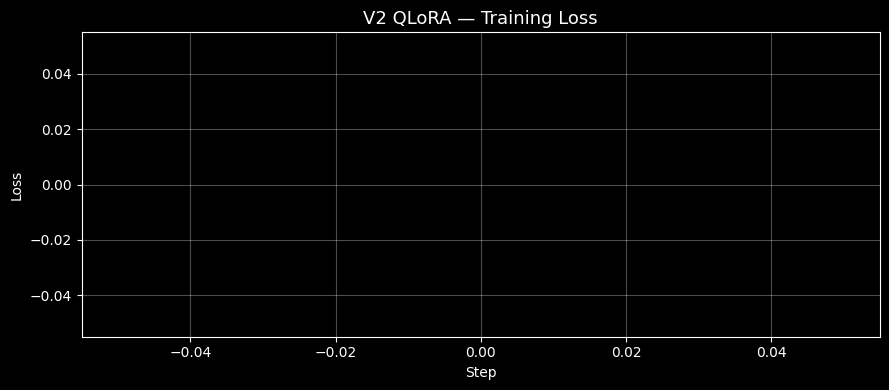

MLflow not available: list index out of range
Training loss chart will be available after running benchmark.py


In [8]:
import matplotlib.pyplot as plt
import mlflow

# Pull loss from MLflow
try:
    client = mlflow.tracking.MlflowClient()
    runs   = client.search_runs(
        experiment_ids=["0"],
        filter_string="tags.mlflow.runName = 'v2_qlora_finetune'",
        order_by=["start_time DESC"],
        max_results=1,
    )
    if runs:
        run_id  = runs[0].info.run_id
        history = client.get_metric_history(run_id, "train_loss")
        steps   = [m.step for m in history]
        losses  = [m.value for m in history]

        plt.figure(figsize=(9, 4))
        plt.plot(steps, losses, color="#f5a623", linewidth=1.5, alpha=0.8)
        plt.title("V2 QLoRA — Training Loss", fontsize=13)
        plt.xlabel("Step");  plt.ylabel("Loss")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(ROOT / "mlflow_runs/v2_loss_curve.png", dpi=120)
        plt.show()
        print(f"Steps logged: {len(steps)}  |  Final loss: {losses[-1]:.4f}")
    else:
        print("No MLflow run found — run finetune.py first.")
except Exception as e:
    print(f"MLflow not available: {e}")
    print("Training loss chart will be available after running benchmark.py")

## 4. Generate Text

In [9]:
# Load model + adapters for inference
clear_gpu()
print(f"VRAM before load: {vram_used()}")

from v2_finetuned.generate import load_model, generate_text

model, tokeniser = load_model()
print(f"VRAM after load : {vram_used()}")

VRAM before load: 0.5 / 8 GB
Loading tokeniser from /home/urmila/PycharmProjects/LanguageModel/v2_finetuned/adapters
Loading base model: Qwen/Qwen2.5-1.5B-Instruct


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Merging LoRA adapters from /home/urmila/PycharmProjects/LanguageModel/v2_finetuned/adapters
Model ready.
VRAM after load : 1.7 / 8 GB


In [10]:
# ── Short generation ──────────────────────────────────────────────────────
SEED = "The spaceship landed on"
print(f"Seed: {repr(SEED)}\n")
print("-" * 60)
print(generate_text(SEED, max_new_tokens=150, temperature=0.7))

Seed: 'The spaceship landed on'

------------------------------------------------------------
The landing was a smooth process. The ship's thrusters had slowed its descent to just above the surface of the planet, so that it could gently land without causing any damage to either the spacecraft or the ground.

As soon as the ship touched down, the crew rushed out onto the surface and began surveying their surroundings. They were greeted by a vast desert landscape with dunes stretching for miles in every direction. The sky was a deep shade of orange and red, and the air was thick with dust from the desert winds.

After spending some time exploring the area, they decided to head back to the ship to restock supplies and refuel. They quickly assembled into teams and headed towards the nearest fuel station. As they approached, they saw a


In [11]:
# ── Paragraph generation ──────────────────────────────────────────────────
SEED = "The alien vessel emerged from hyperspace and"
print(f"Seed: {repr(SEED)}\n")
print("=" * 60)
print(generate_text(SEED, max_new_tokens=300, temperature=0.7))
print("=" * 60)

Seed: 'The alien vessel emerged from hyperspace and'

In a burst of light, the ship materialized in front of them. The crew aboard the spaceship had been prepared for such an eventuality, but they were still taken aback by the sheer size and power of the approaching vessel.

The vessel was massive, its hull made of some kind of unknown substance that gleamed in the dimly lit chamber where it had landed. Its wings extended outward like those of a giant insect, allowing it to glide smoothly through space without the need for propulsion.

The crew could see that the alien creature inside was different than anything they had encountered before. It seemed to be made of some sort of organic matter, with tentacles protruding from its body that moved in a way that was both graceful and unpredictable.

As the creature opened its eyes, the crew realized that they were looking at something truly strange. They saw a faceless being, its features indistinct but its expression one of pure curiosity a

In [12]:
# ── V1 vs V2 side-by-side comparison ─────────────────────────────────────
# Run this after V1 training is done to see the improvement directly
SEED = "Captain Chen stared at the dying star and"   # ← change this

print("── V2 QLoRA ──────────────────────────────────────────────")
v2_out = generate_text(SEED, max_new_tokens=200, temperature=0.7)
print(v2_out)
print()
print("(Run the V1 generate cell to compare side-by-side)")

── V2 QLoRA ──────────────────────────────────────────────
continued. The ship began to shake violently, and Captain Chen knew that they were about to collide with the star.

He quickly activated the emergency procedures, hoping that his crew would survive. However, he soon realized that it was too late. The ship's systems were overloaded, and they could not sustain the impact of such a powerful force.

The ship shattered into pieces, and Captain Chen watched as his men fought for survival in the chaos. Some managed to escape, but others were crushed by the debris or suffocated by the intense heat generated from the collision.

In the end, only a few survived, and they found themselves stranded on the surface of the star. They had no way of knowing how long they had been alive, and they did not know what lay ahead.

As they waited for rescue, Captain Chen thought back to their journey and wondered if they would ever return home. He also wondered if there was any hope for humanity after

## 5. Evaluate — Benchmark Metrics

In [13]:
# Full evaluation — ~20 min for 100 samples
# Use --samples 20 equivalent for a quick smoke test first

from v2_finetuned.evaluate import run_evaluation

# Smoke test first (20 samples, ~4 min)
print("Running smoke test (20 samples)...")
results = run_evaluation(n_samples=20)
print("\nSmoke test passed ✅  — running full eval (100 samples)...")
results = run_evaluation(n_samples=100)

Running smoke test (20 samples)...
Loading 20 val samples...
Loading model for evaluation...
Loading tokeniser from /home/urmila/PycharmProjects/LanguageModel/v2_finetuned/adapters
Loading base model: Qwen/Qwen2.5-1.5B-Instruct


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Merging LoRA adapters from /home/urmila/PycharmProjects/LanguageModel/v2_finetuned/adapters
Model ready.
Computing perplexity...
  Perplexity: 34.7736
Computing BLEU-2 and BLEU-4...
  BLEU-2: 0.0128  |  BLEU-4: 0.002
Computing inference speed...
  Speed: 35.13 tokens/sec
Computing genre consistency score...
  Genre score: 0.0

── V2 Benchmark Results ───────────────────────────────────
  model: V2_QLoRA_Qwen2.5-1.5B
  adapter_dir: /home/urmila/PycharmProjects/LanguageModel/v2_finetuned/adapters
  n_eval_samples: 20
  word_perplexity: 34.7736
  bleu2: 0.0128
  bleu4: 0.002
  inference_tokens_per_sec: 35.13
  genre_consistency_score: 0.0

  Saved → /home/urmila/PycharmProjects/LanguageModel/v2_finetuned/eval_results_v2.json

Smoke test passed ✅  — running full eval (100 samples)...
Loading 100 val samples...
Loading model for evaluation...
Loading tokeniser from /home/urmila/PycharmProjects/LanguageModel/v2_finetuned/adapters
Loading base model: Qwen/Qwen2.5-1.5B-Instruct


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Merging LoRA adapters from /home/urmila/PycharmProjects/LanguageModel/v2_finetuned/adapters
Model ready.
Computing perplexity...
  Perplexity: 34.7736
Computing BLEU-2 and BLEU-4...
  BLEU-2: 0.0153  |  BLEU-4: 0.0056
Computing inference speed...
  Speed: 36.17 tokens/sec
Computing genre consistency score...
  Genre score: 0.0

── V2 Benchmark Results ───────────────────────────────────
  model: V2_QLoRA_Qwen2.5-1.5B
  adapter_dir: /home/urmila/PycharmProjects/LanguageModel/v2_finetuned/adapters
  n_eval_samples: 100
  word_perplexity: 34.7736
  bleu2: 0.0153
  bleu4: 0.0056
  inference_tokens_per_sec: 36.17
  genre_consistency_score: 0.0

  Saved → /home/urmila/PycharmProjects/LanguageModel/v2_finetuned/eval_results_v2.json


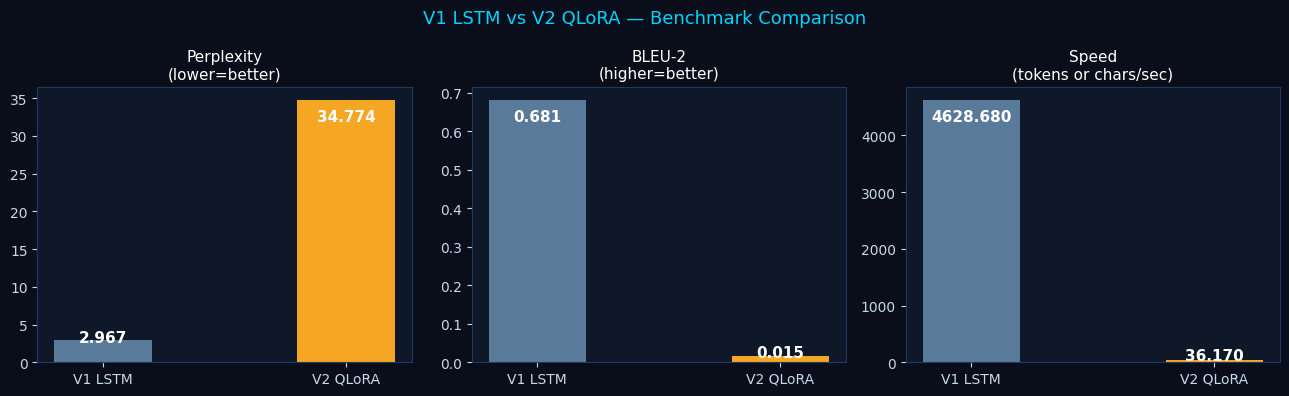

Perplexity change : +1071.9%  (negative = better)
BLEU-2 change     : -97.8%  (positive = better)


In [16]:
# ── V1 vs V2 comparison chart ─────────────────────────────────────────────
import json, matplotlib.pyplot as plt
import numpy as np

V1_PATH = ROOT / "v1_baseline/eval_results_v1.json"
V2_PATH = ROOT / "v2_finetuned/eval_results_v2.json"

v1 = json.loads(V1_PATH.read_text()) if V1_PATH.exists() else {}
v2 = json.loads(V2_PATH.read_text()) if V2_PATH.exists() else {}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
comparisons = [
    ("Perplexity\n(lower=better)",
     [v1.get("char_perplexity",0), v2.get("word_perplexity",0)]),
    ("BLEU-2\n(higher=better)",
     [v1.get("bleu2",0),           v2.get("bleu2",0)]),
    ("Speed\n(tokens or chars/sec)",
     [v1.get("inference_chars_per_sec",0), v2.get("inference_tokens_per_sec",0)]),
]

bar_colors = ["#5a7a9a", "#f5a623"]
for ax, (label, vals) in zip(axes, comparisons):
    bars = ax.bar(["V1 LSTM", "V2 QLoRA"], vals, color=bar_colors, width=0.4)
    ax.set_title(label, fontsize=11)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val * 0.92,
                f"{val:.3f}", ha="center", fontsize=11,
                color="white", fontweight="bold")
    ax.set_facecolor("#0f1829")
    ax.tick_params(colors="#c8d8e8")
    for spine in ax.spines.values():
        spine.set_edgecolor("#1e3a5f")

fig.patch.set_facecolor("#090e1a")
plt.suptitle("V1 LSTM vs V2 QLoRA — Benchmark Comparison",
             color="#00d4ff", fontsize=13)
plt.tight_layout()
plt.savefig(ROOT / "mlflow_runs/v1_vs_v2.png", dpi=120,
            facecolor=fig.get_facecolor())
plt.show()

# Print deltas
if v1 and v2:
    ppl_delta  = (v2.get("word_perplexity",0) - v1.get("char_perplexity",0)) \
                  / v1.get("char_perplexity",1) * 100
    bleu_delta = (v2.get("bleu2",0) - v1.get("bleu2",0)) \
                  / max(v1.get("bleu2",1e-9),1e-9) * 100
    print(f"Perplexity change : {ppl_delta:+.1f}%  (negative = better)")
    print(f"BLEU-2 change     : {bleu_delta:+.1f}%  (positive = better)")

## ✅ V2 Complete

| Item | Value |
|---|---|
| Base model | `Qwen/Qwen2.5-1.5B-Instruct` |
| Fine-tuning | 4-bit QLoRA (`r=16`, `alpha=32`) |
| Training data | 50k instruction-format SciFi samples |
| Adapters | `v2_finetuned/adapters/` |
| Benchmark results | `v2_finetuned/eval_results_v2.json` |

**Next notebook:** `V3_AgenticPipeline.ipynb` — LangGraph multi-agent story generation.